In [2]:
# This notebook explores the geometry of the unembedding (output) matrix of a pretrained GPT-2 model.
# 
# Specifically, we:
# - Extract the unembedding matrix (the weights mapping hidden states to vocabulary logits).
# - Analyze its structure using PCA to understand the dimensionality and variance explained by principal components.
# - Visualize the spectrum of explained variance to identify "elbow points" and estimate the effective rank.
# - The goal is to gain insight into the curvature, redundancy, and geometric properties of the unembedding space,
#   which may relate to how the model represents and distinguishes vocabulary tokens.
# 
# Ultimately, we want to understand:
# - How many directions in embedding space are important for output token discrimination (rank of matrix)
# - If we can take layer activations after running on a large sample batch / gathering in temporal dimension 
# - ... and see Curvature of the Activation space - thus helping us to find critical points and classify them

In [4]:
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import numpy as np
import torch
from transformers import GPT2LMHeadModel
import networkx as nx
import numpy as np
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt

In [2]:
# Load GPT2 model
model = GPT2LMHeadModel.from_pretrained('gpt2')

# Get unembedding matrix (word embeddings)
unembedding_matrix = model.lm_head.weight.detach()

elbow point PC: 5
n components to explain 80% of variance: 435


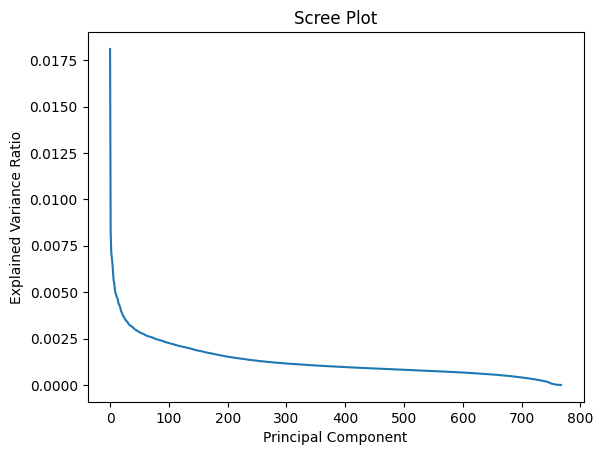

In [27]:
# PCA on unembedding matrix
# pca = PCA(n_components=2)
# pca.fit(unembedding_matrix)
# transformed_unembedding_matrix = pca.fit_transform(unembedding_matrix)

# PCA on unembedding matrix
# plt.scatter(transformed_unembedding_matrix[:, 0], transformed_unembedding_matrix[:, 1])
# plt.show()

# explained variance for each principal component
pca = PCA()
pca.fit(unembedding_matrix)

# get elbow point
elbow_point = np.argmax(np.abs(np.diff(pca.explained_variance_ratio_[2:], n=2)))
print('elbow point PC:', elbow_point+2)

# find n components to explain 80% of variance
n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.8)
print('n components to explain 80% of variance:', n_components)

assert np.sum(pca.explained_variance_ratio_) == 1
# scree plot
plt.plot(pca.explained_variance_ratio_)
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.show()

In [17]:
len(pca.explained_variance_ratio_)

768

In [135]:
def estimate_tangent_space_curvature(data, k=100, n_components=10,  first_m_points=None):
    neighbors = NearestNeighbors(n_neighbors=k).fit(data)
    curvatures = []
    for i, point in enumerate(data):
        if first_m_points is not None and i > first_m_points:
            break
        indices = neighbors.kneighbors(point.reshape(1,-1), return_distance=False)[0]
        local_points = data[indices]
        
        # PCA for tangent space
        pca = PCA()
        pca.fit(local_points) #  - local_points.mean(axis=0)
        
        # Curvature is the sum of variances beyond the first `d` dimensions
        explained_variance = pca.explained_variance_ratio_
        curvature = np.sum(explained_variance[n_components:])  # Example for 2D manifolds
        curvatures.append(curvature)
    return np.array(curvatures)

In [36]:
estimate_tangent_space_curvature(unembedding_matrix, first_m_points=1000, k=100, n_components=10)

array([0.50462987, 0.51509816, 0.51864238, ..., 0.25831106, 0.25833198,
       0.49317792])

In [ ]:
def get_plane_equation(plane):
    pca = PCA(2)    
    pca.fit(plane)
    np.cross(pca.components_[0], pca.components_[1])
    # plane equation ax+by+cz+d=0
    # a,b,c are the normal vector
    # d is the distance from the origin
    normal_vector = np.cross(pca.components_[0], pca.components_[1])
    d = -np.dot(normal_vector, plane[0])
    plane_equation = np.array([normal_vector[0], normal_vector[1], normal_vector[2], d])
    return plane_equation


def find_intersection_line(plane1, plane2):
    """
    Find the intersection line of two planes given their equations:
    a1*x + b1*y + c1*z + d1 = 0
    a2*x + b2*y + c2*z + d2 = 0

    Parameters:
        plane1 (np.ndarray): Coefficients [a1, b1, c1, d1] for the first plane.
        plane2 (np.ndarray): Coefficients [a2, b2, c2, d2] for the second plane.

    Returns:
        point (np.ndarray): A point on the intersection line.
        direction (np.ndarray): Direction vector of the intersection line.
    """
    # Extract coefficients
    a1, b1, c1, d1 = plane1
    a2, b2, c2, d2 = plane2

    # Direction vector is given by the cross product of the normals
    normal1 = np.array([a1, b1, c1])
    normal2 = np.array([a2, b2, c2])
    direction = np.cross(normal1, normal2)

    # Check if the planes are parallel (direction vector is zero)
    if np.allclose(direction, 0):
        raise ValueError("The planes are parallel and do not intersect.")

    # Solve for a point on the intersection line using a linear system
    # Ax = b, where A is the coefficient matrix, and b is the right-hand side vector.
    A = np.array([[a1, b1, c1],
                  [a2, b2, c2],
                  [direction[0], direction[1], direction[2]]])
    b = np.array([-d1, -d2, 0])  # The third equation ensures the solution lies on the line

    # Use least-squares to find a point on the line
    point = np.linalg.lstsq(A, b, rcond=None)[0]

    return point, direction

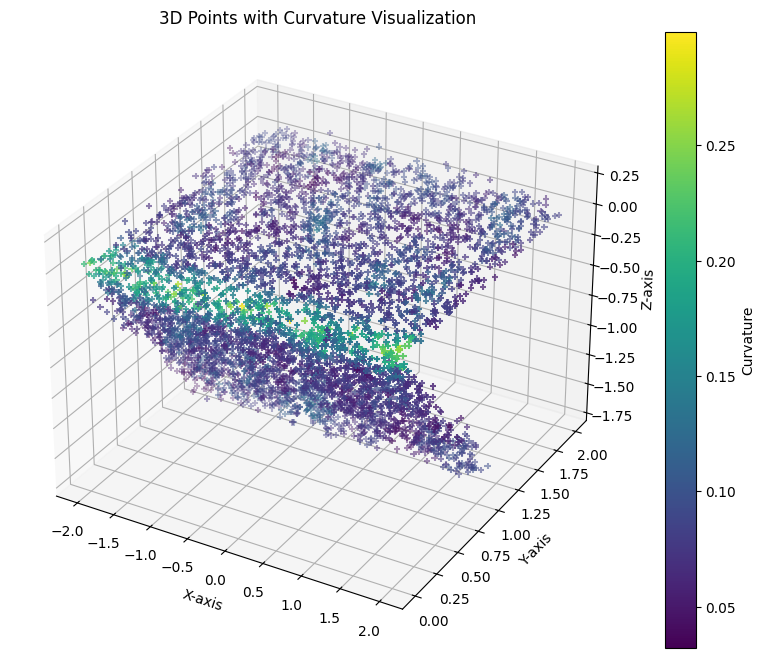

In [174]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from matplotlib.colors import Normalize
import numpy as np

def generate_intersecting_planes(n_points=5000, angle=45, noise=0.05):
    """
    Generate two intersecting planes in 3D at a specified angle.
    
    Parameters:
        n_points (int): Number of points to generate for each plane.
        angle (float): Angle between the two planes in degrees.
        noise (float): Standard deviation of noise added to points.
    
    Returns:
        points (np.ndarray): Array of 3D points forming the two intersecting planes.
    """
    # Generate first plane
    x1 = np.random.uniform(-2, 2, n_points // 2)
    y1 = np.random.uniform(-2, 2, n_points // 2)
    z1 = 0 + np.random.normal(0, noise, n_points // 2)
    plane1 = np.vstack((x1, y1, z1)).T

    # Generate second plane rotated by the specified angle
    x2 = np.random.uniform(-2, 2, n_points // 2)
    z2 = np.random.uniform(-2, 2, n_points // 2)
    y2 = 0 + np.random.normal(0, noise, n_points // 2)
    plane2 = np.vstack((x2, y2, z2)).T

    # Rotate second plane by the specified angle
    theta = np.radians(angle)
    rotation_matrix = np.array([[1, 0, 0],
                                 [0, np.cos(theta), -np.sin(theta)],
                                 [0, np.sin(theta), np.cos(theta)]])
    plane2 = plane2 @ rotation_matrix.T

    plane1_equation = get_plane_equation(plane1)
    plane2_equation = get_plane_equation(plane2)

    # find intersection line from plane equations
    # a_1x+b_1y+c_1z+d_1=a_2x+b_2y+c_2z+d_2 
    # a_1x+b_1y+c_1z+d_1=0
    # a_2x+b_2y+c_2z+d_2=0
    # solve for x,y,z
    intersection_point, intersection_direction = find_intersection_line(plane1_equation, plane2_equation)
    
    # truncate the planes above the intersection line
    truncate_by_coord = 1
    plane1 = plane1[plane1[:, truncate_by_coord] > intersection_direction[truncate_by_coord]]
    plane2 = plane2[plane2[:, truncate_by_coord] > intersection_direction[truncate_by_coord]]
    # Combine planes
    points = np.vstack((plane1, plane2))
    return points

def visualize_curvature(points, curvatures):
    """
    Visualize curvature of points in 3D by PCA-based tangent space curvature.
    
    Parameters:
        points (np.ndarray): Array of 3D points.
        n_neighbors (int): Number of neighbors used to estimate local curvature.
    """
    # Normalize curvature for colormap
    norm = Normalize(vmin=curvatures.min(), vmax=curvatures.max())
    colors = plt.cm.viridis(norm(curvatures))

    # Plot 3D points colored by curvature
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=colors, s=20, marker='+')
    mappable = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
    mappable.set_array(curvatures)
    plt.colorbar(mappable, ax=ax, label="Curvature")
    ax.set_title("3D Points with Curvature Visualization")
    ax.set_xlabel("X-axis")
    ax.set_ylabel("Y-axis")
    ax.set_zlabel("Z-axis")
    plt.show()

# Generate intersecting planes and visualize curvature
points = generate_intersecting_planes(n_points=10000, angle=35, noise=0.05)# Compute curvature using PCA
curvatures = estimate_tangent_space_curvature(points, k=50, n_components=2)
visualize_curvature(points, curvatures)

In [172]:
from sklearn.manifold import Isomap
def compute_curvature_isomap(X, n_neighbors=10, n_components=2):
    isomap = Isomap(n_neighbors=n_neighbors, n_components=n_components)
    embedding = isomap.fit_transform(X)

    # Geodesic distances
    geodesic_distances = isomap.dist_matrix_

    # Euclidean distances
    euclidean_distances = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=2)

    # Curvature as geodesic deviation
    curvature = np.mean(geodesic_distances - euclidean_distances, axis=1)
    return curvature

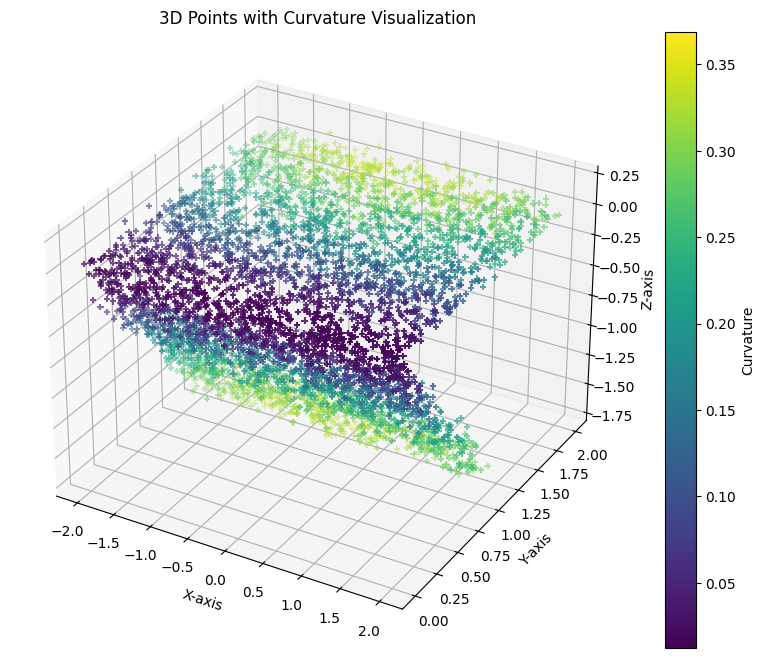

In [182]:
curvatures = compute_curvature_isomap(points, n_neighbors=80, n_components=2)
visualize_curvature(points, curvatures)

In [183]:
from scipy.sparse.csgraph import shortest_path
from sklearn.neighbors import kneighbors_graph

# Construct k-NN graph
geodesic_graph = kneighbors_graph(points, n_neighbors=80, mode='distance')

# Compute shortest paths (geodesic distances)
geodesic_distances = shortest_path(geodesic_graph, directed=False)

In [201]:
geodesic_graph.getcol(2732)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 75 stored elements and shape (4971, 1)>

In [208]:
geodesic_distances[:,1732].nonzero()[0].shape[0]

4970

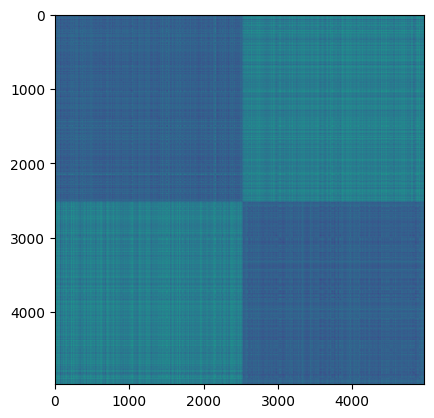

In [185]:
plt.imshow(geodesic_distances)
plt.show()

In [ ]:
import seaborn as sns
sns.clustermap(1-geodesic_distances)

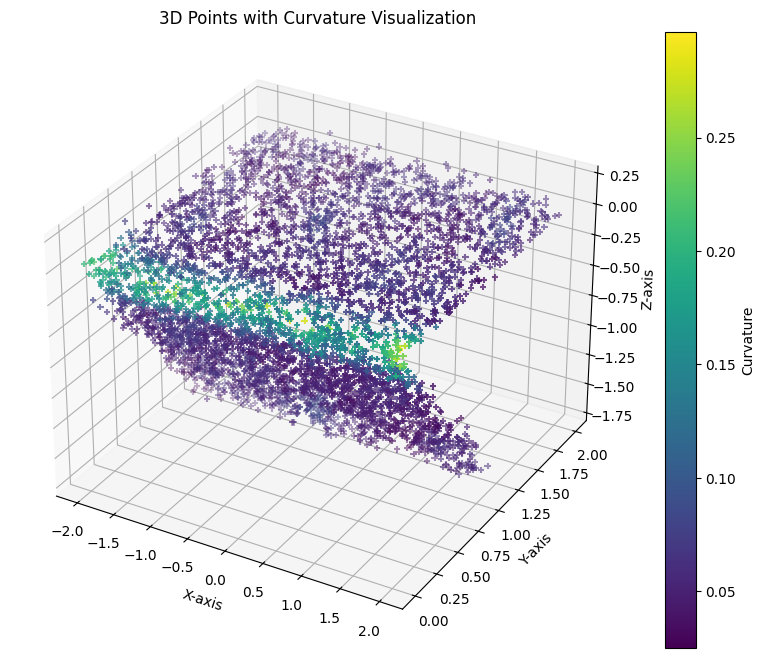

In [181]:
from sklearn.neighbors import kneighbors_graph
from sklearn.decomposition import PCA

def geodesic_weighted_curvature(X, n_neighbors=10):
    # Compute geodesic distance graph
    geodesic_graph = kneighbors_graph(X, n_neighbors=n_neighbors, mode='distance')
    geodesic_distances = geodesic_graph.toarray()
    
    curvatures = []
    for i in range(len(X)):
        # Find neighbors based on geodesic distances
        neighbors_idx = np.where(geodesic_distances[i] > 0)[0]
        local_points = X[neighbors_idx]
        
        # Perform PCA on local points
        pca = PCA()
        pca.fit(local_points)
        
        # Estimate curvature from non-dominant directions
        explained_variance = pca.explained_variance_ratio_
        curvature = np.sum(explained_variance[2:])  # Curvature for a 2D manifold
        curvatures.append(curvature)
    
    return np.array(curvatures)

curvatures = geodesic_weighted_curvature(points, n_neighbors=80)
visualize_curvature(points, curvatures)

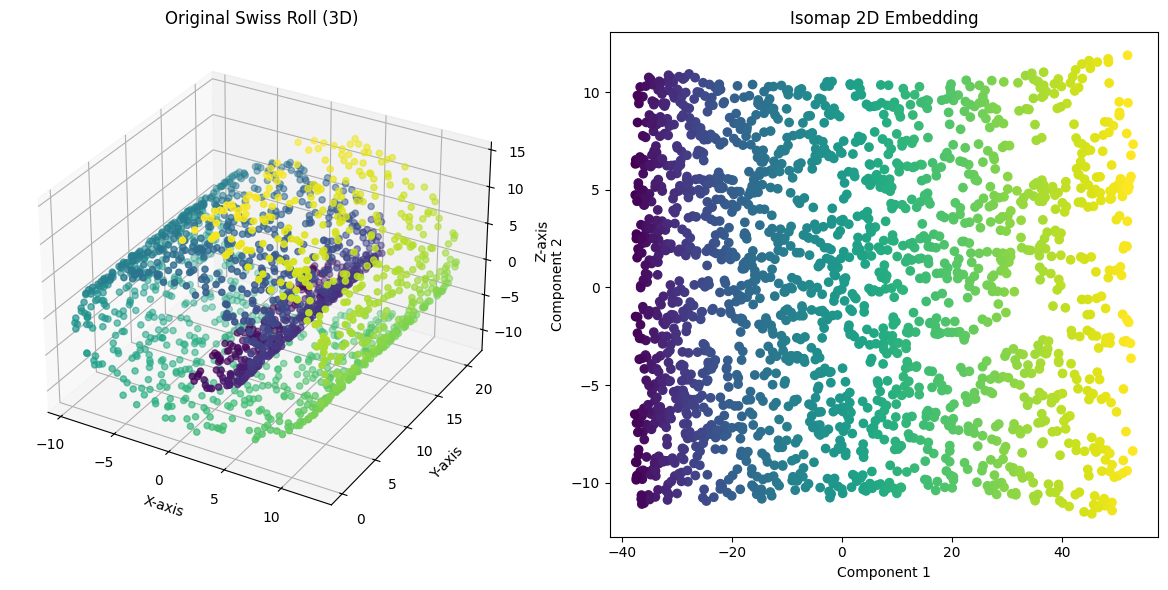

In [154]:
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap
from sklearn.datasets import make_swiss_roll

# Generate Swiss Roll dataset
n_samples = 2000
noise = 0.05
X, color = make_swiss_roll(n_samples, noise=noise, random_state=42)

# Apply Isomap
n_neighbors = 15
n_components = 2
isomap = Isomap(n_neighbors=n_neighbors, n_components=n_components)
X_transformed = isomap.fit_transform(X)

# Plot original Swiss Roll in 3D
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(121, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=plt.cm.viridis)
ax.set_title("Original Swiss Roll (3D)")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")

# Plot Isomap 2D embedding
ax2 = fig.add_subplot(122)
ax2.scatter(X_transformed[:, 0], X_transformed[:, 1], c=color, cmap=plt.cm.viridis)
ax2.set_title("Isomap 2D Embedding")
ax2.set_xlabel("Component 1")
ax2.set_ylabel("Component 2")

plt.tight_layout()
plt.show()

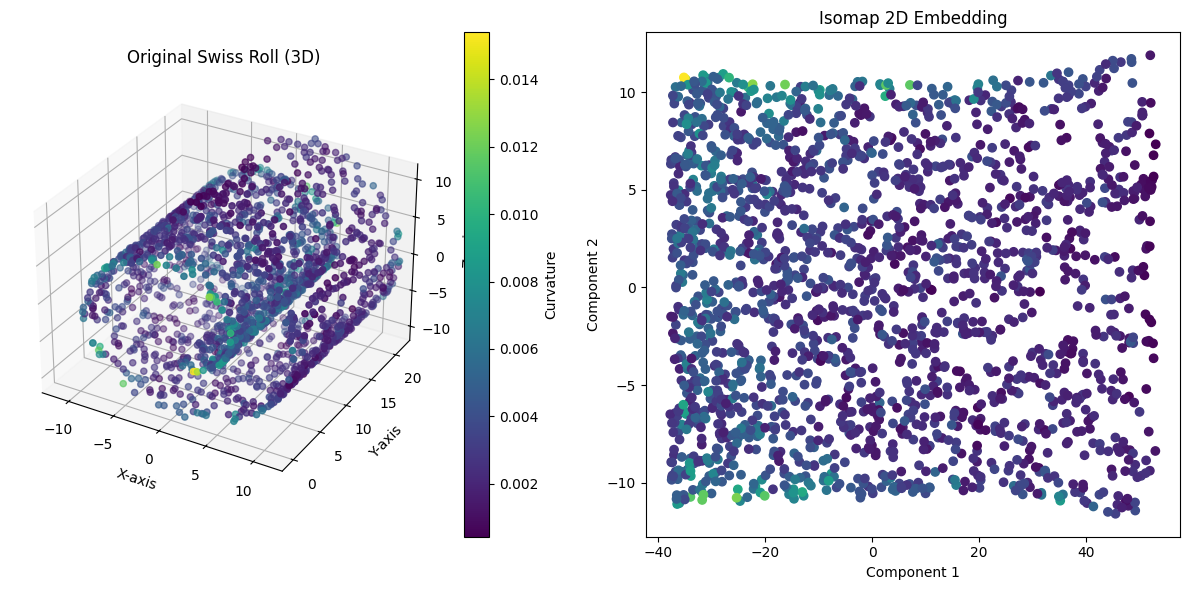

In [163]:
curvatures = estimate_tangent_space_curvature(X, k=20, n_components=2)

def plot_swiss_roll_3d_colored_by_curvature(X, curvatures):
    norm = Normalize(vmin=curvatures.min(), vmax=curvatures.max())
    curvature_colors = plt.cm.viridis(norm(curvatures))

    # Plot original Swiss Roll in 3D
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(121, projection='3d')
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=curvature_colors)
    mappable = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
    mappable.set_array(curvatures)
    plt.colorbar(mappable, ax=ax, label="Curvature")

    ax.set_xlim(-13, 13)
    ax.set_ylim(-2, 23)
    ax.set_zlim(-12, 12)
    ax.set_title("Original Swiss Roll (3D)")
    ax.set_xlabel("X-axis")
    ax.set_ylabel("Y-axis")
    ax.set_zlabel("Z-axis")

    # Plot Isomap 2D embedding
    ax2 = fig.add_subplot(122)
    ax2.scatter(X_transformed[:, 0], X_transformed[:, 1], c=curvature_colors)
    ax2.set_title("Isomap 2D Embedding")
    ax2.set_xlabel("Component 1")
    ax2.set_ylabel("Component 2")

    plt.tight_layout()
    plt.show()

plot_swiss_roll_3d_colored_by_curvature(X, curvatures)

In [176]:
curvature = compute_curvature_isomap(X, n_neighbors=10)

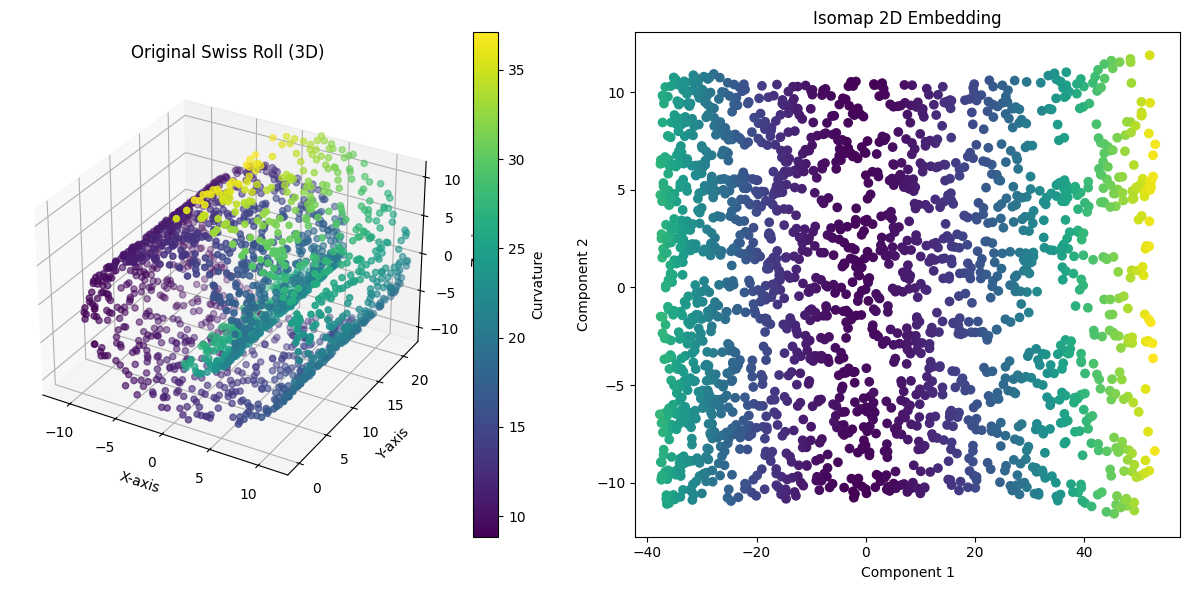

In [177]:
plot_swiss_roll_3d_colored_by_curvature(X, curvature)